In [ ]:
#pip install keras-tuner

### Importing Libraries and Dataset

In [ ]:
# === Core ===
import numpy as np
import pandas as pd

# === Plotting ===
import matplotlib.pyplot as plt
import seaborn as sns  # optional

# === Scikit-learn ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # OneHotEncoder optional
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier, plot_tree           # optional
from sklearn.ensemble import RandomForestClassifier                  # optional
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# === TensorFlow / Keras ===
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import Dense, Dropout, Flatten          # Flatten optional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop                # keep both if you use both
from tensorflow.keras.metrics import AUC

# === Keras Tuner ===
import keras_tuner as kt

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, average_precision_score

from scipy.stats import randint, uniform, loguniform
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.utils import resample
import numpy as np, pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd drive/MyDrive/Colab Notebooks/

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks


In [ ]:
# Load the dataset
raw_data = pd.read_csv('Task_3_and_4_Loan_Data.csv', index_col=0)

### Exploratory Data Analysis

In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 8153374 to 5533570
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   credit_lines_outstanding  10000 non-null  int64  
 1   loan_amt_outstanding      10000 non-null  float64
 2   total_debt_outstanding    10000 non-null  float64
 3   income                    10000 non-null  float64
 4   years_employed            10000 non-null  int64  
 5   fico_score                10000 non-null  int64  
 6   default                   10000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 625.0 KB


In [ ]:
raw_data.describe()

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [ ]:
raw_data.columns

Index(['credit_lines_outstanding', 'loan_amt_outstanding',
       'total_debt_outstanding', 'income', 'years_employed', 'fico_score',
       'default'],
      dtype='object')

In [ ]:
data_cleaned = raw_data.copy()
data_cleaned = data_cleaned.apply(lambda x: x.replace("?",np.nan).astype('float'))
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 8153374 to 5533570
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   credit_lines_outstanding  10000 non-null  float64
 1   loan_amt_outstanding      10000 non-null  float64
 2   total_debt_outstanding    10000 non-null  float64
 3   income                    10000 non-null  float64
 4   years_employed            10000 non-null  float64
 5   fico_score                10000 non-null  float64
 6   default                   10000 non-null  float64
dtypes: float64(7)
memory usage: 625.0 KB


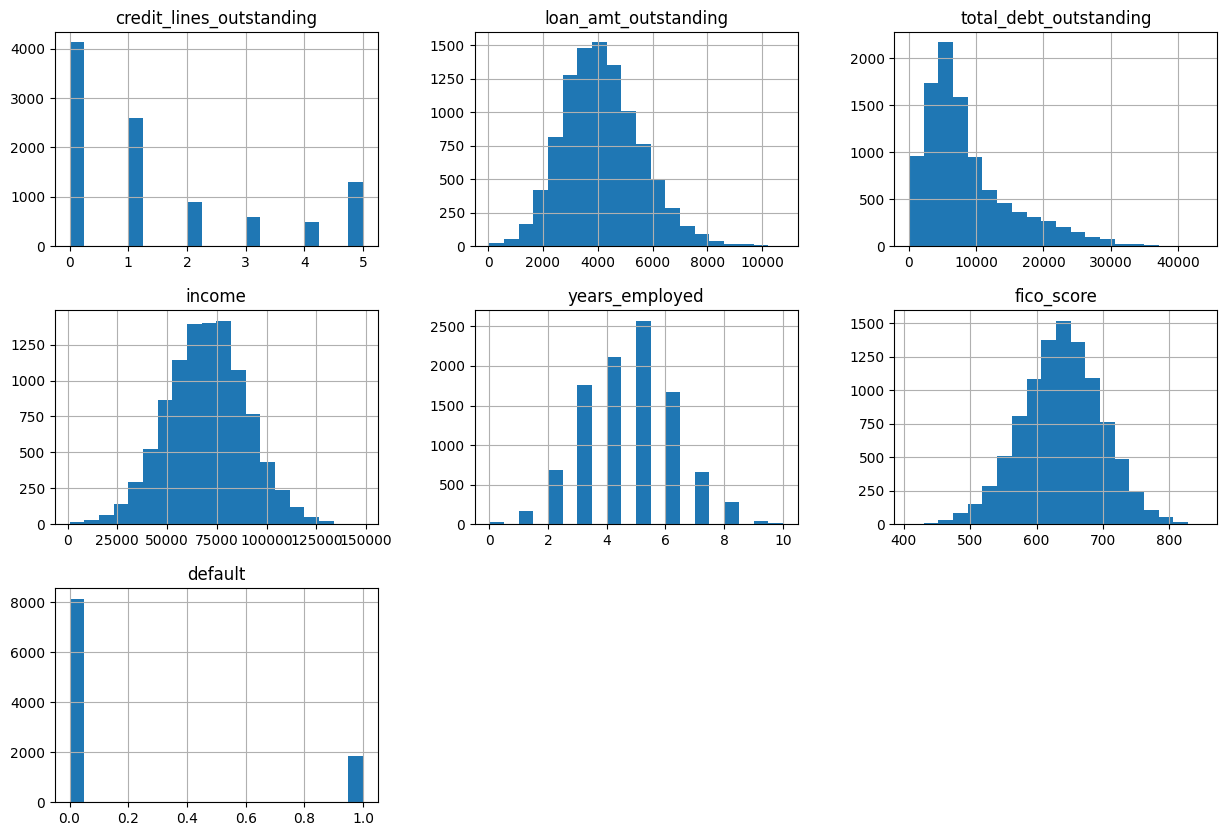

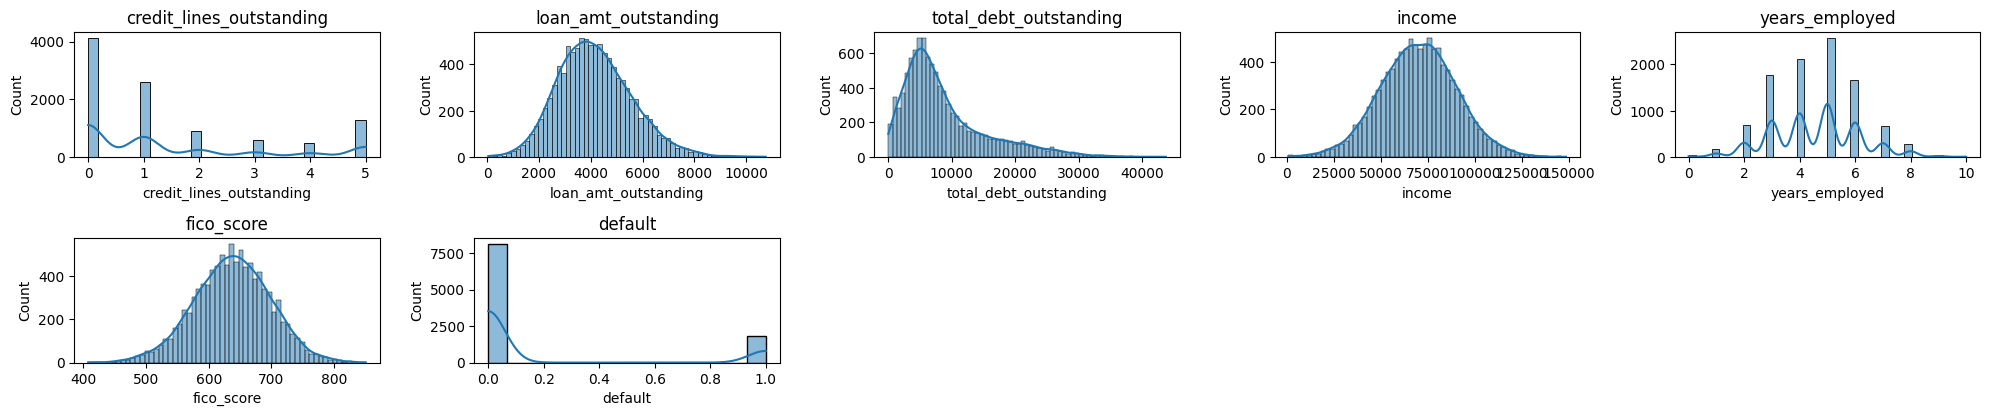

In [ ]:
#Histograms
data_cleaned.hist(bins=20, figsize=(15, 10))
plt.show()

# Visualizing distributions of features
plt.figure(figsize=(20, 10))
for i, col in enumerate(data_cleaned.columns):
    plt.subplot(5, 5, i+1)
    sns.histplot(data_cleaned[col], kde=True)
    plt.title(col)
    plt.tight_layout()

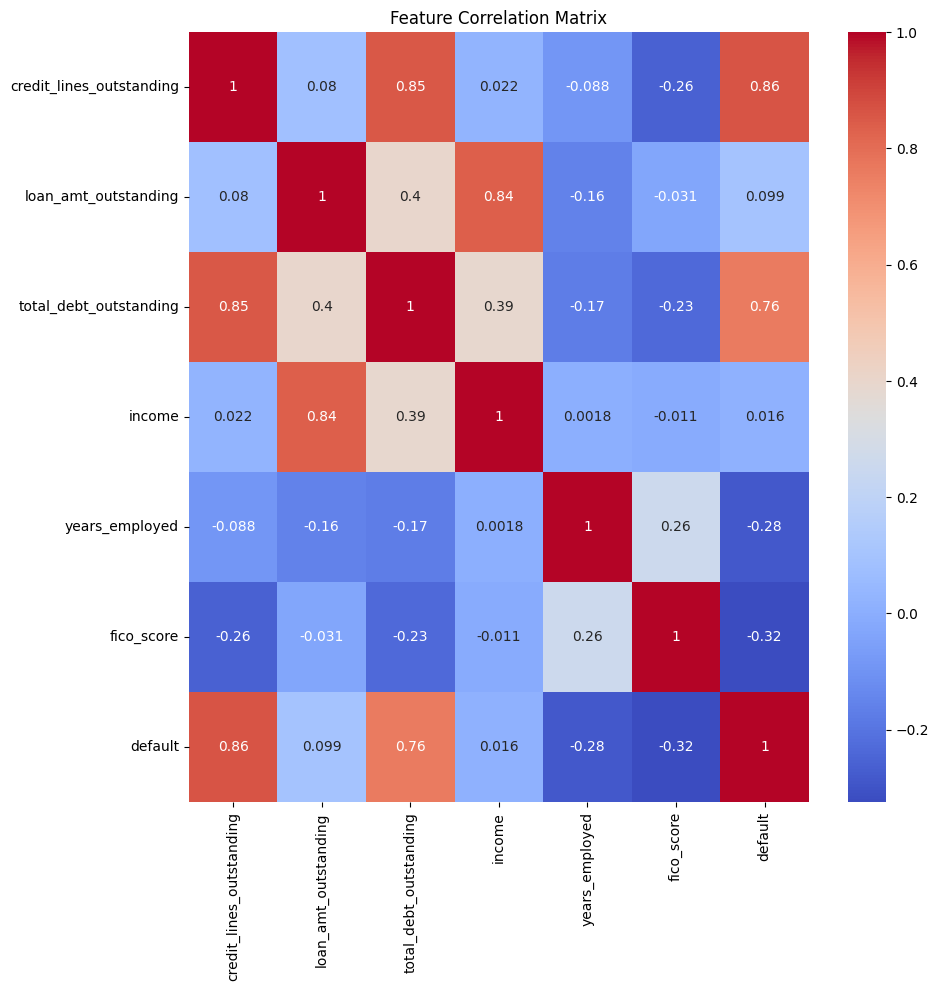

In [ ]:
# Correlation analysis
plt.figure(figsize=(10, 10))
sns.heatmap(data_cleaned.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

Text(0.5, 0, 'FICO score')

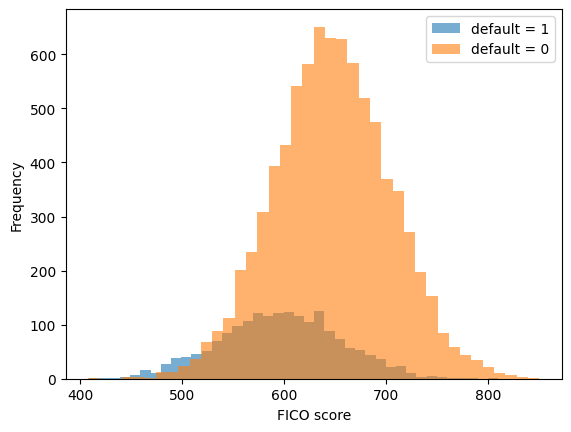

In [ ]:
data_default = data_cleaned[data_cleaned['default']==1]
data_nondefault = data_cleaned[data_cleaned['default']!=1]
data_default['fico_score'].plot(kind='hist',bins=40,alpha=0.6,label='default = 1')
data_nondefault['fico_score'].plot(kind='hist',bins=40,alpha=0.6,label='default = 0')
plt.legend()
plt.xlabel('FICO score')

Text(0.5, 0, 'Income')

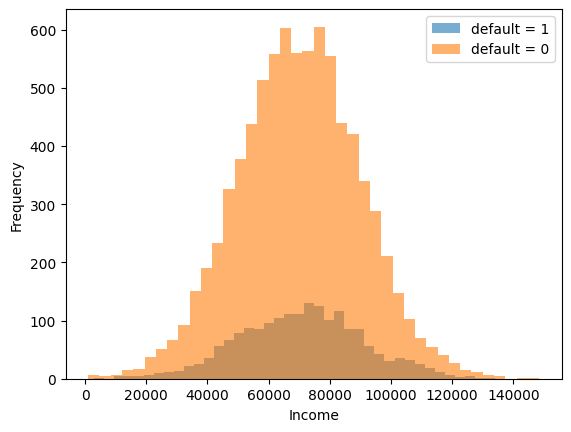

In [ ]:
data_default['income'].plot(kind='hist',bins=40,alpha=0.6,label='default = 1')
data_nondefault['income'].plot(kind='hist',bins=40,alpha=0.6,label='default = 0')
plt.legend()
plt.xlabel('Income')

Text(0.5, 0, 'Total Debt Outstanding')

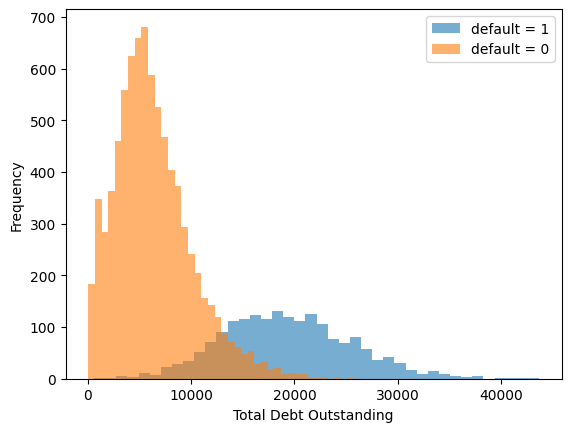

In [ ]:
data_default['total_debt_outstanding'].plot(kind='hist',bins=40,alpha=0.6,label='default = 1')
data_nondefault['total_debt_outstanding'].plot(kind='hist',bins=40,alpha=0.6,label='default = 0')
plt.legend()
plt.xlabel('Total Debt Outstanding')

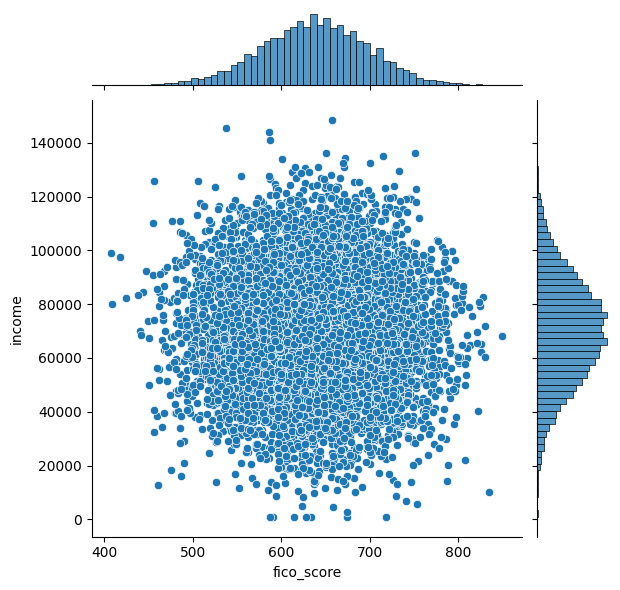

In [ ]:
sns.jointplot(x='fico_score',y='income',data=data_cleaned)

Text(0.5, 0, 'loan_amt_outstanding')

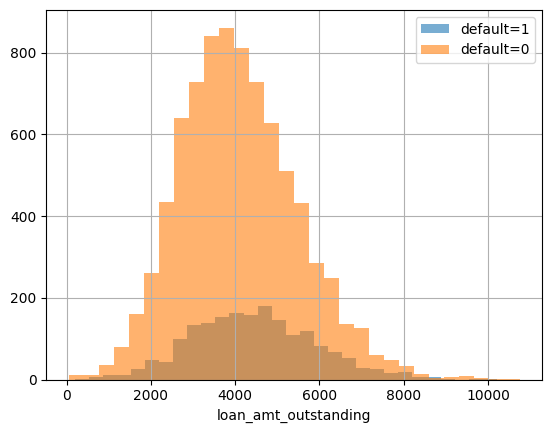

In [ ]:
data_default['loan_amt_outstanding'].hist(bins=30,alpha=0.6,label='default=1')
data_nondefault['loan_amt_outstanding'].hist(bins=30,alpha=0.6,label='default=0')
plt.legend()
plt.xlabel('loan_amt_outstanding')

Text(0.5, 0, 'income')

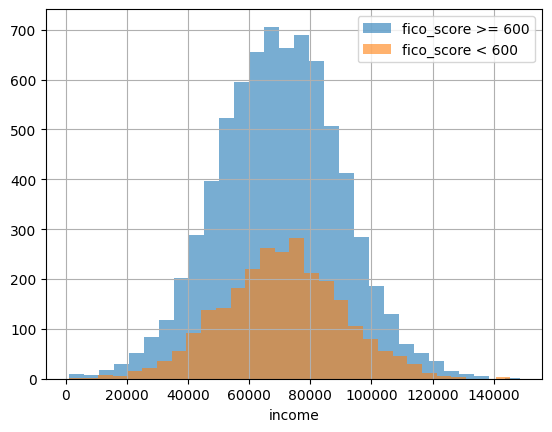

In [ ]:
data_cleaned[data_cleaned['fico_score']>=600]['income'].hist(bins=30,alpha=0.6,label='fico_score >= 600')
data_cleaned[data_cleaned['fico_score']<600]['income'].hist(bins=30,alpha=0.6,label='fico_score < 600')
plt.legend()
plt.xlabel('income')

Check for missing values

In [ ]:
data_cleaned.isna().sum()

,0
credit_lines_outstanding,0
loan_amt_outstanding,0
total_debt_outstanding,0
income,0
years_employed,0
fico_score,0
default,0


In [ ]:
data_cleaned.isnull().sum()

,0
credit_lines_outstanding,0
loan_amt_outstanding,0
total_debt_outstanding,0
income,0
years_employed,0
fico_score,0
default,0


Check for duplicates

In [ ]:
print(data_cleaned.duplicated().sum())

0


In [ ]:
numerical_features = data_cleaned.columns
categorical_features = []

In [ ]:
"""
for col in numerical_features:
  data_cleaned[col].fillna(data_cleaned[col].median(), inplace=True)
for col in categorical_features:
  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)

data_cleaned.isnull().sum()
"""

'\nfor col in numerical_features:\n  data_cleaned[col].fillna(data_cleaned[col].median(), inplace=True)\nfor col in categorical_features:\n  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)\n\ndata_cleaned.isnull().sum()\n'

#### Dataset Unbalance Evaluation

In [ ]:
# BALANCE DATASET
# Separate majority and minority classes
target_column = 'default'
print(raw_data[target_column].value_counts(normalize=True))

df_majority = raw_data[raw_data[target_column] == raw_data[target_column].value_counts().idxmax()]
df_minority = raw_data[raw_data[target_column] == raw_data[target_column].value_counts().idxmin()]

# Downsample majority class
df_majority_downsampled = resample(df_majority, replace=False, n_samples=len(df_minority),random_state=42)

# Combine minority and downsampled majority class
data_balanced = pd.concat([df_minority, df_majority_downsampled])

# Shuffle dataset
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(data_balanced[target_column].value_counts(normalize=True))

default
0    0.8149
1    0.1851
Name: proportion, dtype: float64
default
1    0.5
0    0.5
Name: proportion, dtype: float64


In the cell below, different techniques of dealing with an unbalanced dataset are explored. It was eventually decided to apply undersampling of the majority class when tuning the models.

In [ ]:
# Rebuild from the ORIGINAL, unbalanced data (no prior resampling)
X_full = data_cleaned.drop('default', axis=1)
y_full = data_cleaned['default'].astype(int)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

print("Sanity — prevalence train/test:",
      round(float(y_train.mean()), 4), round(float(y_test.mean()), 4))  # expect ~0.17, ~0.17

Sanity — prevalence train/test: 0.1851 0.185


In [ ]:
results = []

X_full = data_cleaned.drop('default', axis=1)
y_full = data_cleaned['default'].astype(int)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.25, stratify=y_full, random_state=42)

# 0) sanity: show prevalence on test
print("Test prevalence (positives rate):", round(float(y_test_full.mean()), 4))

# 1) No rebalancing (natural)
pipe_nat = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000, solver="liblinear"))
])
pipe_nat.fit(X_train_full, y_train_full)
proba_nat = pipe_nat.predict_proba(X_test_full)[:, 1]
pred_nat  = (proba_nat > 0.5).astype(int)
results.append({"strategy":"natural",
                "ROC-AUC": roc_auc_score(y_test_full, proba_nat),
                "PR-AUC": average_precision_score(y_test_full, proba_nat),
                "F1@0.5": f1_score(y_test_full, pred_nat)})

# 2) Class weighting on natural train
pipe_w = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced", solver="liblinear"))
])
pipe_w.fit(X_train_full, y_train_full)
proba_w = pipe_w.predict_proba(X_test_full)[:, 1]
pred_w  = (proba_w > 0.5).astype(int)
results.append({"strategy":"class_weight=balanced",
                "ROC-AUC": roc_auc_score(y_test_full, proba_w),
                "PR-AUC": average_precision_score(y_test_full, proba_w),
                "F1@0.5": f1_score(y_test_full, pred_w)})

# 3) Undersample to ~1:1 (train ONLY), evaluate on original test
y_tr = np.asarray(y_train_full, dtype=int).ravel()
idx_pos = np.where(y_tr == 1)[0]; idx_neg = np.where(y_tr == 0)[0]
target = min(len(idx_pos), len(idx_neg))
pos_sel = resample(idx_pos, replace=False, n_samples=target, random_state=42) if len(idx_pos)>target else idx_pos
neg_sel = resample(idx_neg, replace=False, n_samples=target, random_state=42) if len(idx_neg)>target else idx_neg
idx_bal = np.random.RandomState(42).permutation(np.concatenate([pos_sel, neg_sel]))
X_train_us = X_train_full.iloc[idx_bal] if hasattr(X_train_full, "iloc") else X_train_full[idx_bal]
y_train_us = y_train_full.iloc[idx_bal] if hasattr(y_train_full, "iloc") else y_tr[idx_bal]

pipe_us = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000, solver="liblinear"))
])
pipe_us.fit(X_train_us, y_train_us)
proba_us = pipe_us.predict_proba(X_test_full)[:, 1]
pred_us  = (proba_us > 0.5).astype(int)
results.append({"strategy":"undersample 1:1",
                "ROC-AUC": roc_auc_score(y_test_full, proba_us),
                "PR-AUC": average_precision_score(y_test_full, proba_us),
                "F1@0.5": f1_score(y_test_full, pred_us)})

print(pd.DataFrame(results).round(4))

Test prevalence (positives rate): 0.1852
                strategy  ROC-AUC  PR-AUC  F1@0.5
0                natural      1.0  0.9999  0.9967
1  class_weight=balanced      1.0  0.9999  0.9727
2        undersample 1:1      1.0  0.9999  0.9646


In [ ]:
y = data_balanced['default']
X = data_balanced.drop('default', axis=1)

## split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

#Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype("float32")
X_test  = scaler.transform(X_test).astype("float32")

### Neural Network Modelling

In [ ]:
def build_model(hp: kt.HyperParameters) -> keras.Model:
    # search space
    n_layers   = hp.Int("n_layers", min_value=1, max_value=4, step=1)
    units      = hp.Int("units", min_value=16, max_value=256, step=16)
    dropout    = hp.Choice("dropout", values=[0.0, 0.1, 0.2, 0.3, 0.4])
    l2_reg     = hp.Choice("l2", values=[0.0, 1e-5, 1e-4, 1e-3])
    lr         = hp.Choice("lr", values=[1e-3, 3e-4, 1e-4])

    reg = None if l2_reg == 0.0 else regularizers.l2(l2_reg)

    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    # first hidden
    model.add(layers.Dense(units, activation="relu", kernel_regularizer=reg))
    if dropout > 0: model.add(layers.Dropout(dropout))
    # additional hidden layers
    for i in range(n_layers - 1):
        model.add(layers.Dense(units, activation="relu", kernel_regularizer=reg))
        if dropout > 0: model.add(layers.Dropout(dropout))
    # binary output
    model.add(layers.Dense(1, activation="sigmoid"))

    opt = keras.optimizers.Adam(learning_rate=lr)
    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy", AUC(name="auc")]
    )
    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=20,            # adjust budget
    executions_per_trial=1,   # >1 averages results but costs time
    directory="ktuner_credit_default",
    project_name="nn_binary_sigmoid",
    overwrite=True
)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=5, restore_best_weights=True
)

In [ ]:
plateau = keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6, verbose=0
)

In [ ]:
tuner.search(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=kt.HyperParameters().Choice("batch_size", [32, 64, 128]),  # or add to build_model if you prefer
    callbacks=[early_stop, plateau],
    verbose=1
)

Trial 20 Complete [00h 00m 15s]
val_auc: 0.9995911717414856

Best val_auc So Far: 0.9999870657920837
Total elapsed time: 00h 06m 18s


In [ ]:
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.get_best_models(1)[0]

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
test_results = best_model.evaluate(X_test, y_test, verbose=0)
# Keras returns [loss, accuracy, auc] in this order
test_loss, test_acc, test_auc = test_results
print("Best HPs:", best_hp.values)
print(f"Test — Loss: {test_loss:.4f}  Acc: {test_acc:.4f}  AUC: {test_auc:.4f}")

Best HPs: {'n_layers': 3, 'units': 240, 'dropout': 0.0, 'l2': 0.0, 'lr': 0.001}
Test — Loss: 0.0076  Acc: 0.9968  AUC: 1.0000


In [ ]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 240)            │         1,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 240)            │        57,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 240)            │        57,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           241 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,601 (459.38 KB)

 Trainable params: 117,601 (459.38 KB)

 Non-trainable params: 0 (0.00 B)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


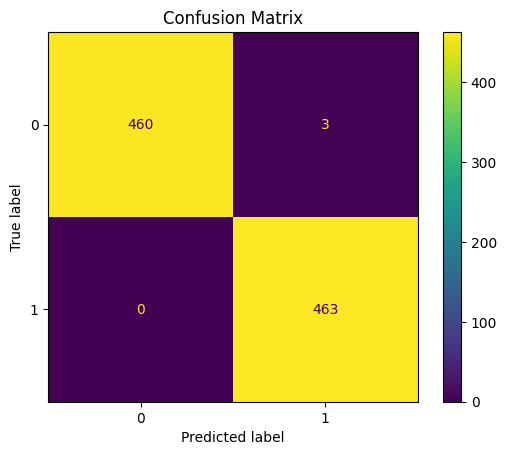

Accuracy: 99.68 %
Precision: 99.36 %
Recall: 100.0 %
F1 Score: 99.68 %


In [ ]:
# predicted probabilities -> convert to binary labels
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32").ravel()   # .ravel() ensures shape (n_samples,)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# metrics
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred) * 100, 2), "%")
print("Recall:", round(recall_score(y_test, y_pred) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, y_pred) * 100, 2), "%")

In [ ]:
nn_perf = {'Accuracy':round(accuracy_score(y_test, y_pred) * 100, 2),
                'Precision':round(precision_score(y_test, y_pred) * 100, 2),
                'Recall':round(recall_score(y_test, y_pred) * 100, 2)}

### XGBoost Modelling

In [ ]:
base = xgb.XGBClassifier(
    tree_method="hist",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "learning_rate": loguniform(0.005, 0.2),
    "n_estimators": randint(200, 1501),
    "max_depth": randint(3, 11),
    "min_child_weight": randint(1, 11),
    "subsample": uniform(0.6, 0.4),          # 0.6–1.0
    "colsample_bytree": uniform(0.5, 0.5),   # 0.5–1.0
    "gamma": uniform(0.0, 5.0),
    "reg_lambda": loguniform(1e-3, 10.0),
    "reg_alpha": loguniform(1e-5, 1.0),
}

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(average_precision_score, needs_proba=True)  # PR-AUC

rs = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_dist,
    n_iter=60,
    scoring="average_precision",
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42,
    error_score="raise"
)

rs.fit(X_train, y_train)
print("Best PR-AUC (CV):", rs.best_score_)
print("Best params:", rs.best_params_)

# --- 3) Train final model on balanced train set with best params; evaluate on original test set ---
best_params = rs.best_params_.copy()
best_params.update(dict(tree_method="hist", eval_metric="aucpr", random_state=42, n_jobs=-1))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best PR-AUC (CV): 0.9997634460643157
Best params: {'colsample_bytree': np.float64(0.9281621459390462), 'gamma': np.float64(2.0225406356109503), 'learning_rate': np.float64(0.13219984959780057), 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 303, 'reg_alpha': np.float64(0.010768254179081208), 'reg_lambda': np.float64(0.0010883991813938126), 'subsample': np.float64(0.6405886171464128)}


#### ROC-AUC Curves and Final Evaluation

In [ ]:
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, roc_auc_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

# 1) Split a validation slice from TRAIN to choose threshold (don’t peek at test)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# 2) Fit same-params model on the training part
xg_val = xgb.XGBClassifier(**rs.best_params_, random_state=42)
xg_val.fit(X_tr, y_tr)

# 3) Pick threshold on VALIDATION
p_val = xg_val.predict_proba(X_val)[:, 1]

# PR-based threshold: maximise F1
prec_v, rec_v, thr_v = precision_recall_curve(y_val, p_val)
f1_v = 2*prec_v*rec_v/(prec_v+rec_v+1e-12)
t_star_pr = thr_v[f1_v[:-1].argmax()]

# (optional) ROC-based threshold: maximise Youden’s J = TPR - FPR
fpr_v, tpr_v, thr_v_roc = roc_curve(y_val, p_val)
t_star_roc = thr_v_roc[(tpr_v - fpr_v).argmax()]

print("Chosen threshold (PR/F1-opt):", float(t_star_pr))
print("Alternative ROC-Youden threshold:", float(t_star_roc))

Chosen threshold (PR/F1-opt): 0.6959306597709656
Alternative ROC-Youden threshold: 0.6959306597709656


In [ ]:
xg_model = xgb.XGBClassifier(**rs.best_params_, random_state=42)
xg_model.fit(X_train, y_train)
y_proba = xg_model.predict_proba(X_test)[:, 1]
y_pred_t = (y_proba >= t_star_roc).astype(int)

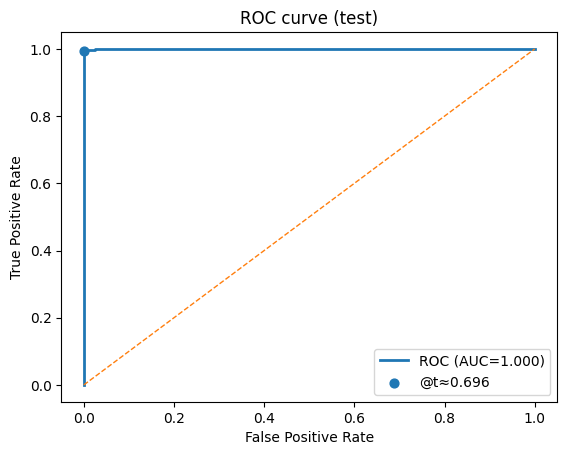

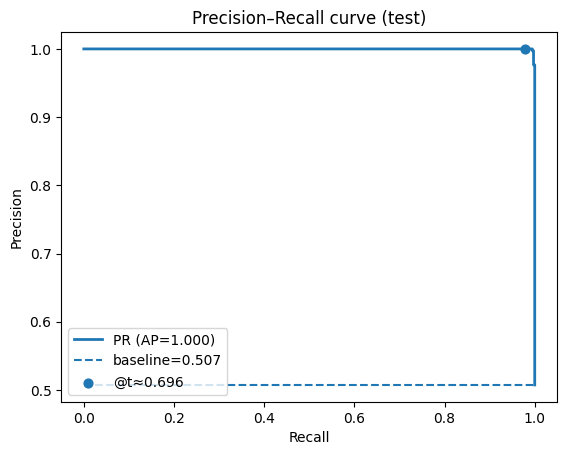

In [ ]:
# ROC
fpr, tpr, roc_thr = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", lw=1)

# mark ROC-Youden (closest threshold to t_star_roc)
k_roc = np.argmin(np.abs(roc_thr - t_star_roc))
plt.scatter(fpr[k_roc], tpr[k_roc], s=40, label=f"@t≈{t_star_roc:.3f}", zorder=3)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (test)")
plt.legend()
plt.show()

# PR
prec, rec, pr_thr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
plt.figure()
plt.plot(rec, prec, lw=2, label=f"PR (AP={ap:.3f})")
plt.hlines(y_test.mean(), 0, 1, linestyles="dashed", label=f"baseline={y_test.mean():.3f}")

# thresholds array has len = len(prec)-1; map threshold idx to point (k+1)
k_pr = np.argmin(np.abs(pr_thr - t_star_pr))
plt.scatter(rec[k_pr + 1], prec[k_pr + 1], s=40, label=f"@t≈{t_star_pr:.3f}", zorder=3)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve (test)")
plt.legend()
plt.show()

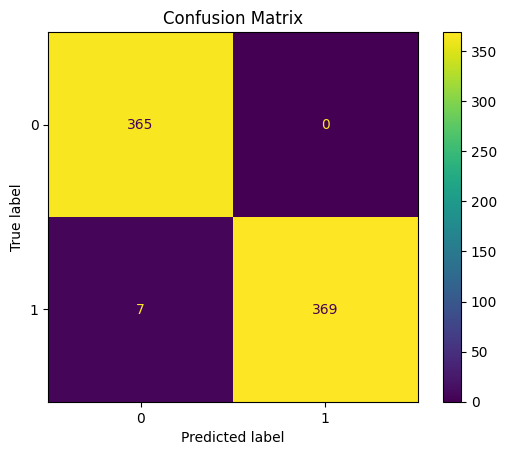

Accuracy: 99.06 %
Precision: 100.0 %
Recall: 98.14 %
F1 Score: 99.06 %
ROC-AUC: 99.99 %
PR-AUC: 99.99 %


In [ ]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred_t)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# metrics
print("Accuracy:", round(accuracy_score(y_test, y_pred_t) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_t) * 100, 2), "%")
print("Recall:", round(recall_score(y_test, y_pred_t) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, y_pred_t) * 100, 2), "%")
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba) * 100, 2), "%")
print("PR-AUC:", round(average_precision_score(y_test, y_proba) * 100, 2), "%")

In [ ]:
xgb_perf = {'Accuracy':round(accuracy_score(y_test, y_pred_t) * 100, 2),
                'Precision':round(precision_score(y_test, y_pred_t) * 100, 2),
                'Recall':round(recall_score(y_test, y_pred_t) * 100, 2)}

#### Data Leakage and Proxy Features Checks

Given the outstanding results of the models, it was decided to check for potential data leakage and proxy features.

It was found that two features, i. e. *credit_lines_outstanding* and *total_debt_outstanding*, are **very** strong predictors of the target variable. This should investigated in more detail.

In [ ]:
aucs = {}
for c in X_test.columns:
    col = X_test[c]
    if pd.api.types.is_numeric_dtype(col):
        col_filled = col.fillna(col.median())
        try:
            aucs[c] = roc_auc_score(y_test, col_filled)
        except ValueError:
            pass  # e.g. constant column
pd.Series(aucs).sort_values(ascending=False).head(15)

,0
credit_lines_outstanding,0.996889
total_debt_outstanding,0.972683
loan_amt_outstanding,0.618508
income,0.532950
years_employed,0.277678
fico_score,0.268449


In [ ]:
res = []
res.append({
    "scenario": "All features",
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "PR-AUC":  average_precision_score(y_test, y_proba),
    "F1@0.5":  f1_score(y_test, y_pred_t),
    "Precision@0.5": precision_score(y_test, y_pred_t),
    "Recall@0.5":    recall_score(y_test, y_pred_t),
})

In [ ]:
# --- Strict features: drop suspected proxies ---
drop_cols = ["credit_lines_outstanding", "total_debt_outstanding"]  # adjust if needed
X_train_strict = X_train.drop(columns=drop_cols, errors="ignore")
X_test_strict  = X_test.drop(columns=drop_cols,  errors="ignore")

m_strict = xgb.XGBClassifier(**rs.best_params_, tree_method="hist", eval_metric="aucpr",
                             random_state=42, n_jobs=-1, verbosity=0)
m_strict.fit(X_train_strict, y_train)

proba_strict = m_strict.predict_proba(X_test_strict)[:, 1]
y_pred_strict = (proba_strict >= 0.5).astype(int)

res
res.append({
    "scenario": "Strict (drop proxies)",
    "ROC-AUC": roc_auc_score(y_test, proba_strict),
    "PR-AUC":  average_precision_score(y_test, proba_strict),
    "F1@0.5":  f1_score(y_test, y_pred_strict),
    "Precision@0.5": precision_score(y_test, y_pred_strict),
    "Recall@0.5":    recall_score(y_test, y_pred_strict),
})

import pandas as pd
print(pd.DataFrame(res).round(4))

                scenario  ROC-AUC  PR-AUC  F1@0.5  Precision@0.5  Recall@0.5
0           All features   0.9999  0.9999  0.9906         1.0000      0.9814
1  Strict (drop proxies)   0.7458  0.7413  0.7049         0.7078      0.7021


### Conclusions

In [ ]:
performance_data = {
    'Neural Network': nn_perf,
    'XGBoost': xgb_perf
}

df_perf = pd.DataFrame.from_dict(performance_data, orient='index')

print("--- Your Performance DataFrame ---")
print(df_perf)

--- Your Performance DataFrame ---
                Accuracy  Precision  Recall
Neural Network     99.68      99.36  100.00
XGBoost            99.06     100.00   98.14


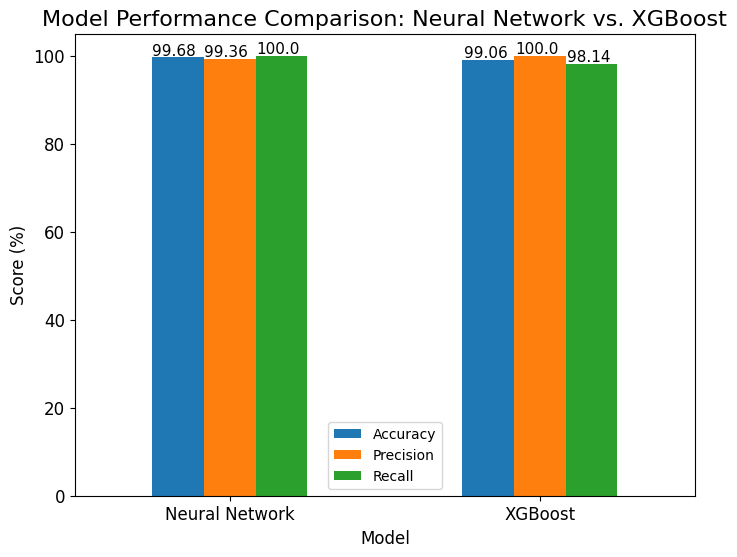

In [ ]:
# Create the bar plot directly from the DataFrame
ax = df_perf.plot(kind='bar',
                  figsize=(8, 6),
                  legend=True,
                  fontsize=12)

# --- Step 4: Add Professional Touches ---
# Set the title and labels
plt.title('Model Performance Comparison: Neural Network vs. XGBoost', fontsize=16)
plt.ylabel('Score (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0) # Keep the model names horizontal

# Add the exact values on top of each bar for clarity
for p in ax.patches:
    ax.annotate(str(p.get_height()),
                (p.get_x() * 1.005, p.get_height() * 1.005),
                fontsize=11)

# Display the plot
plt.show()